# Quantization vs. Adversarial Robustness — Reliable Pipeline

Uses pretrained CIFAR-10 checkpoints (no training from scratch). Each heavy
computation step is its own cell, wrapped in try/except, with incremental
CSV checkpointing so a Colab disconnect doesn't lose prior results.

In [1]:
# --- Cell: installs (local) ---
# On Colab this ran every session. Locally you only need to do this ONCE,
# ideally from a terminal (see requirements.txt), not from inside the
# notebook on every run. This cell now just verifies the packages are
# importable and tells you what to do if not, instead of always hitting
# the network.
import importlib
missing = [pkg for pkg in ("torchattacks", "autoattack") if importlib.util.find_spec(pkg) is None]
if missing:
    raise ImportError(
        f"Missing packages: {missing}. Install once from a terminal with your venv "
        f"activated:\n  pip install -r requirements.txt"
    )
print("torchattacks / autoattack available.")


torchattacks / autoattack available.


In [2]:
# --- Cell: imports ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import numpy as np
import pandas as pd
import copy, os, traceback

import torchattacks
from autoattack import AutoAttack

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

RESULTS_CSV = "results.csv"

device: cpu


In [3]:
# --- Cell: data (local) ---
# finetune_loader: small slice of CIFAR-10 train set, used ONLY for the short
#   QAT fine-tuning step (a few epochs). Not used for training from scratch.
# eval_loader: fixed CIFAR-10 test subset used for all attack evaluations.
#
# CIFAR10_ROOT should point at the folder that CONTAINS "cifar-10-batches-py".
# If you have the tar.gz, extract it so you end up with:
#   <CIFAR10_ROOT>/cifar-10-batches-py/data_batch_1 ... test_batch ...
import os

CIFAR10_ROOT = os.environ.get("CIFAR10_ROOT", "./")

expected = os.path.join(CIFAR10_ROOT, "cifar-10-batches-py")
if not os.path.isdir(expected):
    raise FileNotFoundError(
        f"Expected extracted CIFAR-10 at {expected!r} but it's not there.\n"
        f"Extract your local cifar-10-python.tar.gz into {CIFAR10_ROOT!r} "
        f"(or set the CIFAR10_ROOT env var) before running this cell."
    )

def get_dataloaders(batch_size=100, eval_n=500, finetune_n=4000):
    transform_train = T.Compose([
        T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor(),
        T.Normalize(mean=(0.4914, 0.4822, 0.4465),
                    std=(0.2023, 0.1994, 0.2010))
    ])
    transform_test = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=(0.4914, 0.4822, 0.4465),
                    std=(0.2023, 0.1994, 0.2010))
    ])

    train_full = torchvision.datasets.CIFAR10(
        root=CIFAR10_ROOT, train=True, download=False, transform=transform_train)
    test_full = torchvision.datasets.CIFAR10(
        root=CIFAR10_ROOT, train=False, download=False, transform=transform_test)

    finetune_subset = torch.utils.data.Subset(train_full, list(range(finetune_n)))
    finetune_loader = torch.utils.data.DataLoader(
        finetune_subset, batch_size=batch_size, shuffle=True, num_workers=2)

    eval_subset = torch.utils.data.Subset(test_full, list(range(eval_n)))
    eval_loader = torch.utils.data.DataLoader(
        eval_subset, batch_size=100, shuffle=False)

    return finetune_loader, eval_loader

finetune_loader, eval_loader = get_dataloaders()


In [4]:
# --- Cell: pretrained models (NO training from scratch) ---
# https://github.com/chenyaofo/pytorch-cifar-models
# resnet20: ~92.6% top-1 on CIFAR-10. mobilenetv2_x1_0: ~93.8% top-1.

PRETRAINED_NAMES = {
    "ResNet20": "cifar10_resnet20",
    "ResNet56": "cifar10_resnet56",
    "MobileNetV2": "cifar10_mobilenetv2_x1_0",
    "VGG16_BN": "cifar10_vgg16_bn",
    "ShuffleNetV2": "cifar10_shufflenetv2_x1_0",
    "RepVGG_A0": "cifar10_repvgg_a0"
}

def load_pretrained(arch_key):
    hub_name = PRETRAINED_NAMES[arch_key]
    model = torch.hub.load("chenyaofo/pytorch-cifar-models", hub_name, pretrained=True)
    return model.to(device).eval()

def sanity_check_accuracy(model, loader):
    """Quick clean-accuracy check -- if this is low, something's wrong
    before you even get to attacks (wrong normalization, wrong checkpoint, etc)."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

In [5]:
# --- Cell: custom fake-quantization (replaces torchao for Conv2d) ---
# torchao's quantize_() only converts nn.Linear (verified: Conv2d weights are
# left as plain torch.nn.Parameter, untouched). Since CNNs are almost all
# Conv2d, that silently quantizes ~nothing. This module quantizes Conv2d AND
# Linear identically, with a toggle between:
#   use_ste=False -> real hard rounding (the actual deployed model; gradient
#                     through round() is ~0 almost everywhere -- this is
#                     where masking would show up if it's present)
#   use_ste=True  -> straight-through estimator (used during QAT fine-tuning
#                     so weight gradients aren't blocked, and during the
#                     BPDA attack so input gradients aren't blocked)
# Forward-pass *values* are identical in both modes -- only the backward
# pass differs -- so toggling this never changes what model you're evaluating,
# only how its gradient is computed.

class FakeQuantSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        return torch.round(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output

def quantize_tensor(t, bits, use_ste):
    if bits is None:
        return t
    qmax = 2 ** (bits - 1) - 1
    scale = t.detach().abs().max() / qmax
    scale = torch.clamp(scale, min=1e-8)
    t_scaled = t / scale
    t_round = FakeQuantSTE.apply(t_scaled) if use_ste else torch.round(t_scaled)
    t_round = torch.clamp(t_round, -qmax - 1, qmax)
    return t_round * scale

class QuantConv2d(nn.Conv2d):
    def forward(self, x):
        bits      = getattr(self, 'bits', None)
        use_ste   = getattr(self, 'use_ste', False)
        quant_act = getattr(self, 'quant_act', True)
        w   = quantize_tensor(self.weight, bits, use_ste)
        out = self._conv_forward(x, w, self.bias)
        if quant_act:
            out = quantize_tensor(out, bits, use_ste)
        return out

class QuantLinear(nn.Linear):
    def forward(self, x):
        bits      = getattr(self, 'bits', None)
        use_ste   = getattr(self, 'use_ste', False)
        quant_act = getattr(self, 'quant_act', True)
        w   = quantize_tensor(self.weight, bits, use_ste)
        out = F.linear(x, w, self.bias)
        if quant_act:
            out = quantize_tensor(out, bits, use_ste)
        return out

def _to_quant_module(mod, bits):
    if isinstance(mod, nn.Conv2d):
        new = QuantConv2d(mod.in_channels, mod.out_channels, mod.kernel_size,
                          mod.stride, mod.padding, mod.dilation, mod.groups,
                          mod.bias is not None, mod.padding_mode)
        new.weight = mod.weight
        if mod.bias is not None: new.bias = mod.bias
        new.bits = bits; new.use_ste = False; new.quant_act = True
        return new
    if isinstance(mod, nn.Linear):
        new = QuantLinear(mod.in_features, mod.out_features, mod.bias is not None)
        new.weight = mod.weight
        if mod.bias is not None: new.bias = mod.bias
        new.bits = bits; new.use_ste = False; new.quant_act = True
        return new
    return None

def _replace_recursive(module, bits):
    for name, child in list(module.named_children()):
        nc = _to_quant_module(child, bits)
        if nc is not None: setattr(module, name, nc)
        else: _replace_recursive(child, bits)

def convert_to_quant(model, bits):
    m = copy.deepcopy(model)
    _replace_recursive(m, bits)
    return m

def set_ste_mode(model, flag):
    for mod in model.modules():
        if isinstance(mod, (QuantConv2d, QuantLinear)):
            mod.use_ste = flag

def count_quant_layers(model):
    return sum(1 for m in model.modules() if isinstance(m, (QuantConv2d, QuantLinear)))

In [6]:
# --- Cell: QAT (real QAT -- fake-quant active DURING fine-tuning) ---
# This is what makes it QAT rather than "fine-tune then PTQ": STE is on
# throughout training so the weights actually adapt to quantization noise.

def prepare_qat(fp32_model, bits, finetune_loader, epochs=3, lr=1e-3):
    m = convert_to_quant(fp32_model, bits)
    set_ste_mode(m, True)       # gradients must flow through rounding to train
    m.train()
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    for epoch in range(epochs):
        running = 0.0
        for x, y in finetune_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(m(x), y)
            loss.backward()
            opt.step()
            running += loss.item()
        print(f"  QAT epoch {epoch+1}/{epochs} avg loss {running/len(finetune_loader):.4f}")
    set_ste_mode(m, False)      # back to real rounding for deployment/eval
    return m.eval()

In [7]:
# --- Cell: attacks ---

CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
CIFAR_STD  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
CLIP_MIN = ((0.0 - CIFAR_MEAN) / CIFAR_STD)
CLIP_MAX = ((1.0 - CIFAR_MEAN) / CIFAR_STD)

def run_fgsm_pgd(model, loader, eps=8/255):
    model.eval()
    fgsm = torchattacks.FGSM(model, eps=eps)
    pgd = torchattacks.PGD(model, eps=eps, alpha=2/255, steps=20, random_start=True)
    out = {}
    for name, atk in [("FGSM", fgsm), ("PGD", pgd)]:
        correct, total = 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            x_adv = atk(x, y)
            with torch.no_grad():
                pred = model(x_adv).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        out[name] = correct / total
    return out

def run_autoattack(model, loader, eps=8/255):
    model.eval()
    adversary = AutoAttack(model, norm="Linf", eps=eps, version="standard", device=device, verbose=False)
    
    correct = 0
    total = 0
    
    # Process batch using native size
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        x_adv = adversary.run_standard_evaluation(x, y, bs=x.size(0))
        
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
            
    return correct / total

def transfer_attack(source_model, target_model, loader, eps=8/255):
    """Craft PGD on source (e.g. FP32), evaluate success on target (e.g. quantized).
    If this beats PGD-on-target directly, that's a masking signal."""
    pgd = torchattacks.PGD(source_model, eps=eps, alpha=2/255, steps=20, random_start=True)
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = pgd(x, y)
        with torch.no_grad():
            pred = target_model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

def bpda_pgd_attack(model, x, y, eps=8/255, alpha=2/255, steps=20):
    """PGD with STE gradients through the quantization rounding step."""
    set_ste_mode(model, True)
    clip_min = CLIP_MIN.to(device)
    clip_max = CLIP_MAX.to(device)
    x_adv = x.clone().detach() + torch.empty_like(x).uniform_(-eps, eps)
    x_adv = torch.max(torch.min(x_adv, clip_max), clip_min).detach()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * grad.sign()
        x_adv = torch.min(torch.max(x_adv, x - eps), x + eps)  # epsilon ball
        x_adv = torch.max(torch.min(x_adv, clip_max), clip_min).detach()  # valid range
    set_ste_mode(model, False)
    return x_adv.detach()

def run_bpda(model, loader, eps=8/255):
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = bpda_pgd_attack(model, x, y, eps=eps)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

def gradient_diagnostics(model, loader):
    """Cheap masking signal independent of attack success rate: fraction of
    near-zero / abnormally large input-gradient entries, comparing hard-round
    (real deployed gradient) vs STE (corrected gradient)."""
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)

    set_ste_mode(model, False)
    x_in = x.clone().requires_grad_(True)
    loss = F.cross_entropy(model(x_in), y)
    g_hard = torch.autograd.grad(loss, x_in)[0].flatten()

    set_ste_mode(model, True)
    x_in2 = x.clone().requires_grad_(True)
    loss2 = F.cross_entropy(model(x_in2), y)
    g_ste = torch.autograd.grad(loss2, x_in2)[0].flatten()
    set_ste_mode(model, False)

    return {
        "frac_zero_grad_hard": (g_hard.abs() < 1e-8).float().mean().item(),
        "frac_zero_grad_ste": (g_ste.abs() < 1e-8).float().mean().item(),
        "grad_norm_hard": g_hard.norm().item(),
        "grad_norm_ste": g_ste.norm().item(),
    }

In [8]:
# --- Cell: run_suite (every attack wrapped individually -- one failure
# doesn't lose the others) ---

def run_suite(model, loader, name, fp32_ref=None, eps=8/255):
    model.eval()
    results = {"model": name}

    try:
        results["clean_acc"] = sanity_check_accuracy(model, loader)
    except Exception as e:
        print(f"  [WARN] clean_acc failed for {name}: {e}")
        results["clean_acc"] = None

    try:
        results.update(run_fgsm_pgd(model, loader, eps=eps))
    except Exception as e:
        print(f"  [WARN] FGSM/PGD failed for {name}: {e}")
        results["FGSM"] = None; results["PGD"] = None

    try:
        results["AutoAttack"] = run_autoattack(model, loader, eps=eps)
    except Exception as e:
        print(f"  [WARN] AutoAttack failed for {name}: {e}")
        results["AutoAttack"] = None

    if fp32_ref is not None:
        try:
            results["Transfer_from_FP32"] = transfer_attack(fp32_ref, model, loader, eps=eps)
        except Exception as e:
            print(f"  [WARN] transfer_attack failed for {name}: {e}")
            results["Transfer_from_FP32"] = None

    if isinstance(model, type(model)) and count_quant_layers(model) > 0:
        try:
            results["BPDA_PGD"] = run_bpda(model, loader, eps=eps)
        except Exception as e:
            print(f"  [WARN] BPDA failed for {name}: {e}")
            results["BPDA_PGD"] = None
        try:
            results.update(gradient_diagnostics(model, loader))
        except Exception as e:
            print(f"  [WARN] gradient_diagnostics failed for {name}: {e}")

    return results

In [9]:
# --- Cell: build model registry (pretrained checkpoints + quantized variants) ---
# Each step wrapped in try/except so one failure (e.g. a hub download hiccup)
# doesn't take down the whole registry build.

model_registry = {}

for arch_key in PRETRAINED_NAMES:
    print(f"\n>>> {arch_key} <<<")
    try:
        fp32 = load_pretrained(arch_key)
        acc = sanity_check_accuracy(fp32, eval_loader)
        print(f"  loaded pretrained {arch_key}, clean acc on eval subset: {acc:.3f}")
        model_registry[f"{arch_key}_FP32"] = (fp32, None)
    except Exception as e:
        print(f"  [FAIL] could not load {arch_key} pretrained checkpoint: {e}")
        traceback.print_exc()
        continue  # can't build quantized variants without the FP32 base

    try:
        int8_ptq = convert_to_quant(fp32, bits=8)
        model_registry[f"{arch_key}_int8_PTQ"] = (int8_ptq, fp32)
    except Exception as e:
        print(f"  [FAIL] int8 PTQ for {arch_key}: {e}")

    try:
        int4_ptq = convert_to_quant(fp32, bits=4)
        model_registry[f"{arch_key}_int4_PTQ"] = (int4_ptq, fp32)
    except Exception as e:
        print(f"  [FAIL] int4 PTQ for {arch_key}: {e}")

    try:
        int8_qat = prepare_qat(fp32, bits=8, finetune_loader=finetune_loader, epochs=3)
        model_registry[f"{arch_key}_int8_QAT"] = (int8_qat, fp32)
    except Exception as e:
        print(f"  [FAIL] int8 QAT for {arch_key}: {e}")
        traceback.print_exc()

print("\nRegistry built:", list(model_registry.keys()))


>>> ResNet20 <<<


Using cache found in C:\Users\xuena/.cache\torch\hub\chenyaofo_pytorch-cifar-models_master


  loaded pretrained ResNet20, clean acc on eval subset: 0.922
  QAT epoch 1/3 avg loss 0.0203
  QAT epoch 2/3 avg loss 0.0193
  QAT epoch 3/3 avg loss 0.0223

>>> ResNet56 <<<


Using cache found in C:\Users\xuena/.cache\torch\hub\chenyaofo_pytorch-cifar-models_master


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet56-187c023a.pt" to C:\Users\xuena/.cache\torch\hub\checkpoints\cifar10_resnet56-187c023a.pt


100%|██████████| 3.39M/3.39M [00:02<00:00, 1.42MB/s]


  loaded pretrained ResNet56, clean acc on eval subset: 0.946
  QAT epoch 1/3 avg loss 0.0037
  QAT epoch 2/3 avg loss 0.0056
  QAT epoch 3/3 avg loss 0.0056

>>> MobileNetV2 <<<


Using cache found in C:\Users\xuena/.cache\torch\hub\chenyaofo_pytorch-cifar-models_master


  loaded pretrained MobileNetV2, clean acc on eval subset: 0.936


KeyboardInterrupt: 

In [ ]:
# Cell: evaluation loop (incremental checkpointing to CSV)

if os.path.exists(RESULTS_CSV):
    df_results = pd.read_csv(RESULTS_CSV)
    done = set(df_results["model"])
else:
    df_results = pd.DataFrame()
    done = set()

for name, (model, ref) in model_registry.items():
    if name in done:
        print(f"Skipping {name} (already in {RESULTS_CSV})")
        continue

    print(f"\nEvaluating {name} ...")

    try:
        res = run_suite(model, eval_loader, name, fp32_ref=ref)
    except Exception as e:
        print(f"  [FAIL] run_suite totally failed for {name}: {e}")
        traceback.print_exc()
        res = {"model": name}

    # Append the new result
    new_row = pd.DataFrame([res])
    df_results = pd.concat([df_results, new_row], ignore_index=True)

    # Checkpoint after every model
    df_results.to_csv(RESULTS_CSV, index=False)

    # Print/display just the new result
    print("Result:")
    display(new_row)

print("\nFinal results:")
display(df_results)

Skipping ResNet20_FP32 (already in results.csv)

Evaluating ResNet20_int8_PTQ ...
Result:


,model,clean_acc,FGSM,PGD,AutoAttack,Transfer_from_FP32,BPDA_PGD,frac_zero_grad_hard,frac_zero_grad_ste,grad_norm_hard,grad_norm_ste
0,ResNet20_int8_PTQ,0.928,0.416,0.074,0.066,0.076,0.012,0.315479,0.315479,0.740299,0.740299



Evaluating ResNet20_int4_PTQ ...
Result:


,model,clean_acc,FGSM,PGD,AutoAttack,Transfer_from_FP32,BPDA_PGD,frac_zero_grad_hard,frac_zero_grad_ste,grad_norm_hard,grad_norm_ste
0,ResNet20_int4_PTQ,0.852,0.214,0.076,0.066,0.144,0.002,0.140742,0.140742,0.982402,0.982402



Evaluating ResNet20_int8_QAT ...
Result:


,model,clean_acc,FGSM,PGD,AutoAttack,Transfer_from_FP32,BPDA_PGD,frac_zero_grad_hard,frac_zero_grad_ste,grad_norm_hard,grad_norm_ste
0,ResNet20_int8_QAT,0.928,0.414,0.082,0.072,0.086,0.016,0.300469,0.300469,0.66095,0.66095



Evaluating MobileNetV2_FP32 ...
Result:


,model,clean_acc,FGSM,PGD,AutoAttack
0,MobileNetV2_FP32,0.936,0.494,0.114,0.094



Evaluating MobileNetV2_int8_PTQ ...


KeyboardInterrupt: 

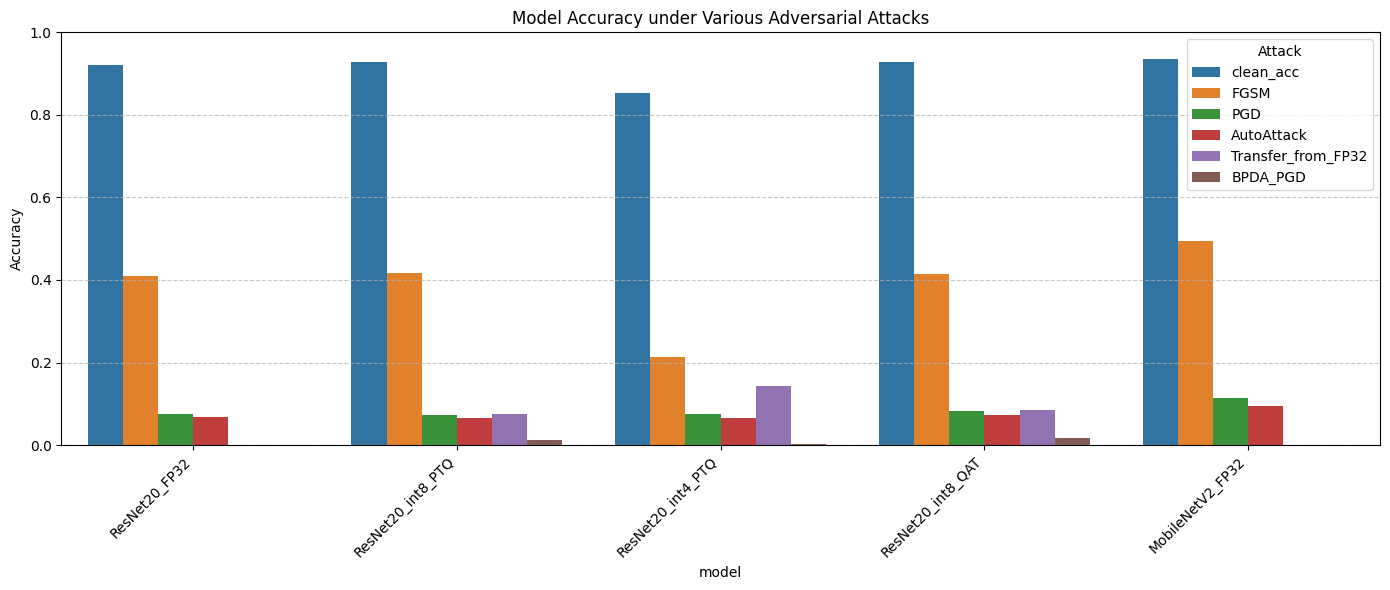

In [ ]:
# --- Cell: visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

acc_cols = [c for c in ["clean_acc", "FGSM", "PGD", "AutoAttack", "Transfer_from_FP32", "BPDA_PGD"]
            if c in df_results.columns]

df_plot = df_results.melt(id_vars="model", value_vars=acc_cols,
                           var_name="Attack", value_name="Accuracy")

plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x="model", y="Accuracy", hue="Attack")
plt.xticks(rotation=45, ha="right")
plt.title("Model Accuracy under Various Adversarial Attacks")
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()


# plt.savefig("accuracy_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# --- Cell: epsilon sweep (computes df_sweep) ---
SWEEP_CSV = "results_sweep.csv"
SWEEP_EPSILONS = [1/255, 2/255, 4/255, 8/255, 16/255]

def run_epsilon_sweep_for_model(model, loader, name, epsilons):
    rows = []
    is_quant = count_quant_layers(model) > 0
    for eps in epsilons:
        row = {"model": name, "epsilon": eps}
        try:
            pgd = torchattacks.PGD(model, eps=eps, alpha=2/255, steps=20, random_start=True)
            correct, total = 0, 0
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                x_adv = pgd(x, y)
                with torch.no_grad():
                    pred = model(x_adv).argmax(1)
                correct += (pred == y).sum().item()
                total += y.size(0)
            row["PGD_acc"] = correct / total
        except Exception as e:
            print(f"  [WARN] PGD sweep failed for {name} eps={eps:.4f}: {e}")
            row["PGD_acc"] = None

        if is_quant:
            try:
                row["BPDA_acc"] = run_bpda(model, loader, eps=eps)
            except Exception as e:
                print(f"  [WARN] BPDA sweep failed for {name} eps={eps:.4f}: {e}")
                row["BPDA_acc"] = None

        rows.append(row)
    return rows

if os.path.exists(SWEEP_CSV):
    df_sweep = pd.read_csv(SWEEP_CSV)
    sweep_done = set(zip(df_sweep["model"], df_sweep["epsilon"].round(6)))
else:
    df_sweep = pd.DataFrame()
    sweep_done = set()

for name, (model, ref) in model_registry.items():
    print(f"Sweeping {name} ...")
    pending_eps = [eps for eps in SWEEP_EPSILONS if (name, round(eps, 6)) not in sweep_done]
    if not pending_eps:
        print(f"  Skipping {name} (already in {SWEEP_CSV})")
        continue
    try:
        rows = run_epsilon_sweep_for_model(model, eval_loader, name, pending_eps)
    except Exception as e:
        print(f"  [FAIL] epsilon sweep totally failed for {name}: {e}")
        traceback.print_exc()
        rows = []
    if rows:
        df_sweep = pd.concat([df_sweep, pd.DataFrame(rows)], ignore_index=True)
        df_sweep.to_csv(SWEEP_CSV, index=False)  # checkpoint after every model

display(df_sweep)
# import matplotlib.pyplot as plt

df_sweep_clean = df_sweep.dropna(subset=["epsilon"])
models_to_plot = df_sweep_clean["model"].unique()

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(5 * len(models_to_plot), 4.5), sharey=True)
if len(models_to_plot) == 1:
    axes = [axes]

for ax, name in zip(axes, models_to_plot):
    sub = df_sweep_clean[df_sweep_clean["model"] == name].sort_values("epsilon")
    ax.plot(sub["epsilon"], sub["PGD_acc"], marker="o", label="PGD")
    if "BPDA_acc" in sub.columns and sub["BPDA_acc"].notna().any():
        ax.plot(sub["epsilon"], sub["BPDA_acc"], marker="s", label="BPDA")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("epsilon")
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Accuracy under attack")
plt.suptitle("Accuracy vs. perturbation budget (plateau-then-cliff = masking signature)")
plt.tight_layout()
plt.show()

Sweeping ResNet20_FP32 ...


KeyboardInterrupt: 